# 1. Imports


In [50]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import apply_affine_transform

# 2. Setting Up the Dataset Path

In [51]:
print(os.getcwd())
BASE_DIR = os.getcwd()
DATADIR = os.path.join(BASE_DIR, "dataset")


c:\Users\habib\Kidney_stone_detection-


 # 3. Preview One Image Per Category

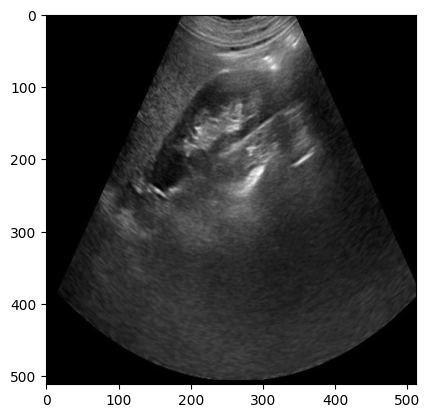

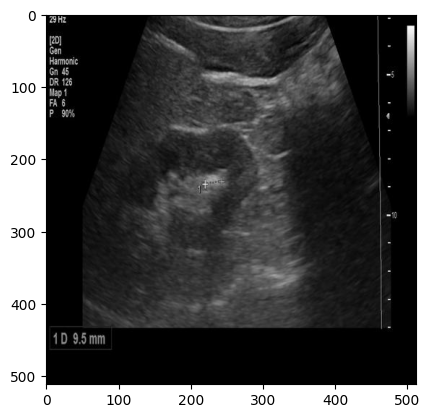

In [52]:

CATEGORIES = ["Normal", "stone"]  # Normal=0, stone=1
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break

# 4. Resize the Image

Original Image shape: (512, 512)
Resized Image shape: (225, 225)


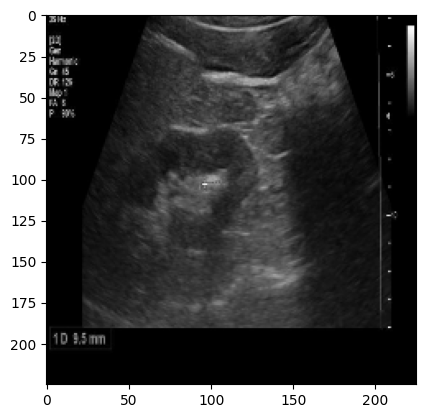

In [53]:
print("Original Image shape:", img_array.shape)  # original size
IMG_SIZE = 225
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap="gray")
print("Resized Image shape:", new_array.shape)  # resized image
plt.show()

# 5. Build the Training Dataset

In [54]:
training_data = []
def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category) # stone=0, Normal=1
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")

create_training_data()
print(len(training_data))  # total number of images loaded

2000


#  6. Shuffle & Separate Features/Labels

In [55]:
random.shuffle(training_data)   # prevents the model from learning order

X = []  # features (images)
y = []  # labels (0 or 1)

for feature, label in training_data:
    X.append(feature)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# 7. Save with Pickle
##### Pickle saves Python objects to disk so you don't re-process images every time

In [56]:
import pickle

# Save X (images)
pickle_out = open("X.pickle", "wb")   # "wb" = write binary
pickle.dump(X, pickle_out)
pickle_out.close()

# Save y (labels)
pickle_out = open("y.pickle", "wb")
pickle.dump(y, pickle_out)
pickle_out.close()

# 8. Load Pickle Back

In [57]:
pickle_in = open("X.pickle", "rb")   # "rb" = read binary
X = pickle.load(pickle_in)

pickle_in = open("y.pickle", "rb")
y = pickle.load(pickle_in)

# 9. Normalize the Images


In [58]:
X = X / 255.0

# 10. Split Dataset into Training, Validation& Testing (70,15,15)

In [59]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1400, 225, 225, 1)
Validation data shape: (300, 225, 225, 1)
Testing data shape: (300, 225, 225, 1)


 # 11. Data Augmentation

In [60]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 12. Visualize Augmented Images

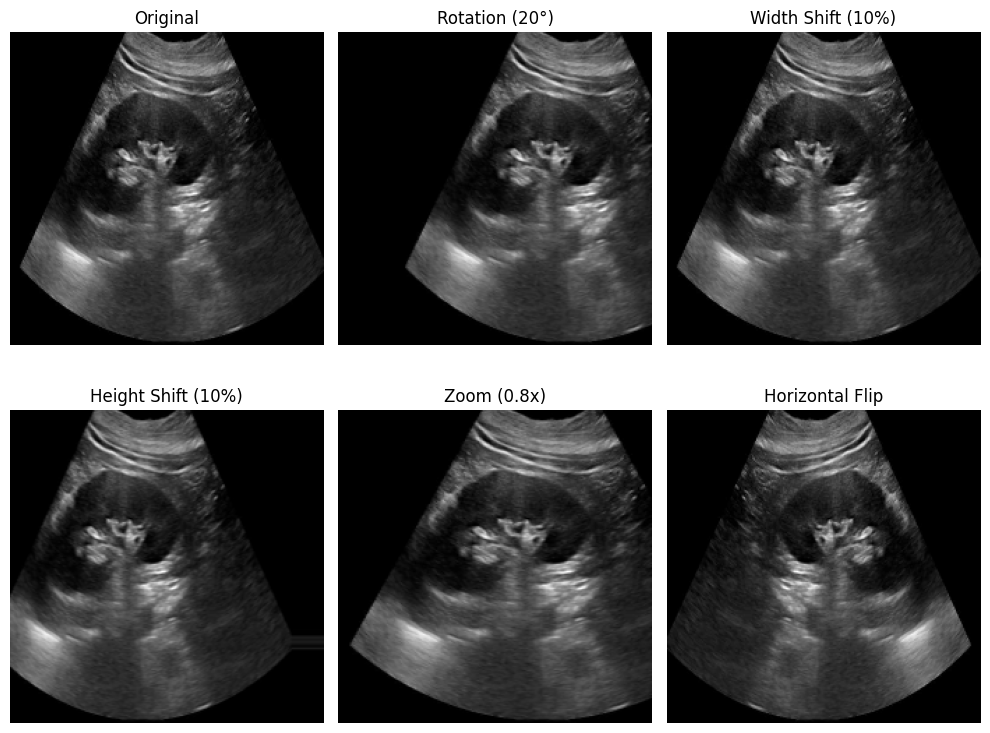

In [61]:
img = X_train[0]  # shape = (225, 225, 1)

plt.figure(figsize=(10,8))

# Original
plt.subplot(2,3,1)
plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Original")
plt.axis("off")

# Rotation
rot = apply_affine_transform(img, theta=20)
plt.subplot(2,3,2)
plt.imshow(rot.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Rotation (20°)")
plt.axis("off")

# Width shift (horizontal)
width_shift = apply_affine_transform(img, tx=IMG_SIZE * 0.1)
plt.subplot(2,3,3)
plt.imshow(width_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Width Shift (10%)")
plt.axis("off")

# Height shift (vertical)
height_shift = apply_affine_transform(img, ty=IMG_SIZE * 0.1)
plt.subplot(2,3,4)
plt.imshow(height_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Height Shift (10%)")
plt.axis("off")

# Zoom
zoom = apply_affine_transform(img, zx=0.8, zy=0.8)
plt.subplot(2,3,5)
plt.imshow(zoom.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Zoom (0.8x)")
plt.axis("off")

# Flip
flip = np.fliplr(img.reshape(IMG_SIZE, IMG_SIZE))
plt.subplot(2,3,6)
plt.imshow(flip, cmap='gray')
plt.title("Horizontal Flip")
plt.axis("off")

plt.tight_layout()
plt.show()

# 13. Effective Dataset Size After Augmentation

In [62]:
BATCH_SIZE = 32
EPOCHS = 10
steps_per_epoch = len(X_train) // BATCH_SIZE

# Total number of samples the model will "see"
total_seen = steps_per_epoch * BATCH_SIZE * EPOCHS

# How much the dataset is effectively increased
multiplier = total_seen / len(X_train)

print("==== DATASET REPORT ====\n")

print(f"Original TOTAL dataset size: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

print("---- AUGMENTATION EFFECT ----\n")

print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Steps per epoch: {steps_per_epoch}")

print(f"\nTotal samples seen during training: {total_seen}")
print(f"Effective dataset size increase: {multiplier:.2f}x")

==== DATASET REPORT ====

Original TOTAL dataset size: 2000
Training set size: 1400
Validation set size: 300
Test set size: 300

---- AUGMENTATION EFFECT ----

Batch size: 32
Epochs: 10
Steps per epoch: 43

Total samples seen during training: 13760
Effective dataset size increase: 9.83x


# MODEL 1 — ResNet50


In [63]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)


## Compile ResNet50

In [64]:
model_resnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train ResNet50

In [65]:
history_resnet = model_resnet.fit(
    X_train_rgb,
    y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.5014 - loss: 3.1007 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss:

## Evaluate ResNet50

In [66]:
acc_resnet = model_resnet.evaluate(X_test_rgb, y_test)[1]
print("ResNet50 Accuracy:", acc_resnet)

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5000 - loss: 0.6931
ResNet50 Accuracy: 0.5


# MODEL 2 — MobileNetV2

In [67]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

C:\Users\habib\AppData\Local\Temp\ipykernel_1400\693092403.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


## Compile MobileNetV2

In [68]:
model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train MobileNetV2

In [69]:
history_mobilenet = model_mobilenet.fit(
    X_train_rgb,
    y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 425ms/step - accuracy: 0.9264 - loss: 1.4490 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 421ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9967 - val_loss: 0.0066
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 464ms/step - accuracy: 0.9993 - loss: 0.0082 - val_accuracy: 0.9967 - val_loss: 0.0464
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 400ms/step - accuracy: 0.9986 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 7.9578e-06
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 381ms/step - accuracy: 0.9993 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.8522e-10
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 404ms/step - accuracy: 1.0000 - loss: 3.1677e-11 - val_accuracy: 1.0000 - val_loss: 2.8741e-09
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 394ms/step - accuracy: 1.0000 - loss: 3.8117e-11 - val_accuracy: 1.0000 - val_loss: 2.9611e-09
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 358ms/step - accuracy: 1.0000 -

## Evaluate MobileNetV2

In [70]:
acc_mobilenet = model_mobilenet.evaluate(X_test_rgb, y_test)[1]
print("MobileNetV2 Accuracy:", acc_mobilenet)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.9967 - loss: 0.0259
MobileNetV2 Accuracy: 0.996666669845581


In [71]:
print("==== MODEL COMPARISON ====\n")

print(f"MobileNetV2: {acc_mobilenet:.4f}")
print(f"ResNet50: {acc_resnet:.4f}")

==== MODEL COMPARISON ====

MobileNetV2: 0.9967
ResNet50: 0.5000
